# Predicted vs Actual Attribution

Compares attributions for:
1. **Predicted** activity (what the model outputs)
2. **Actual** activity (ground truth)
3. **Delta** (what features would need to change to get the correct answer)

In [1]:
import sys
from pathlib import Path
_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir(): break
    _current = _current.parent
sys.path.insert(0, str(_current))
sys.path.insert(0, str(_current / 'src'))

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from src.interpretability.config.helpdesk_config import CONFIG
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability import InterpretabilityTool

%matplotlib inline

In [2]:
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
device = torch.device('cpu')
test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)
eval_helper = Evaluation(model=model, dataset=test_dataset, concept_name=CONFIG.concept_name,
                         growing_num_values=CONFIG.growing_num_values, all_cat=CONFIG.all_cat, all_num=CONFIG.all_num)
tool = InterpretabilityTool(model, model.data_set_categories, device=device)

# Get activity mapping
concept_id = eval_helper.concept_name_id
inv_cats = eval_helper.inverted_suffix_categories[concept_id]
cat_to_idx = {v: k for k, v in inv_cats.items()}

print(f"Cases: {len(eval_helper.cases)}")

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('Variant index', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123.0': 19, '124.0': 20, '125.0': 21, '126.0': 22, '1

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

In [3]:
# Configuration
CASE_NAME = "Case 1261"
PREFIX_LENGTH = 2
SUFFIX_STEP = 0  # Which suffix step to analyze

# Get prefix and ground truth
case = eval_helper.cases[CASE_NAME]
for pl, prefix, suffix in eval_helper._iterate_case(case):
    if pl == PREFIX_LENGTH:
        break

# Ground truth activity
gt_idx = suffix[0][concept_id][0, SUFFIX_STEP].item()
gt_activity = inv_cats.get(gt_idx, f'?{gt_idx}')

# Model prediction
with torch.no_grad():
    predictions, _, _, _ = model(prefix)
cat_preds = predictions[0]
activity_logits = cat_preds[f'{CONFIG.concept_name}_mean']
if activity_logits.dim() == 3:
    activity_logits = activity_logits[SUFFIX_STEP]
pred_idx = activity_logits.argmax(dim=-1).item()
pred_activity = inv_cats.get(pred_idx, f'?{pred_idx}')

is_correct = pred_idx == gt_idx

print(f"Case: {CASE_NAME}, Prefix: {PREFIX_LENGTH}, Suffix step: {SUFFIX_STEP}")
print(f"Predicted: {pred_activity} (class {pred_idx})")
print(f"Actual:    {gt_activity} (class {gt_idx})")
print(f"Correct:   {is_correct}")

Case: Case 1261, Prefix: 2, Suffix step: 0
Predicted: Take in charge ticket (class 13)
Actual:    Resolve ticket (class 11)
Correct:   False


In [ ]:
# Compute attributions for both predicted and actual class
process = ([t.squeeze(0) for t in prefix[0]], [t.squeeze(0) for t in prefix[1]])

print("Computing attribution for PREDICTED class...")
attr_predicted = tool.compute_attribution_map(
    process=process, prefix_length=PREFIX_LENGTH, target=CONFIG.concept_name,
    target_class=pred_idx, suffix_scope='step', suffix_step=SUFFIX_STEP,
    method='integrated_gradients', n_steps=CONFIG.ig_steps
)
print(f"  {attr_predicted.target_description}")

print("\nComputing attribution for ACTUAL class...")
attr_actual = tool.compute_attribution_map(
    process=process, prefix_length=PREFIX_LENGTH, target=CONFIG.concept_name,
    target_class=gt_idx, suffix_scope='step', suffix_step=SUFFIX_STEP,
    method='integrated_gradients', n_steps=CONFIG.ig_steps
)
print(f"  {attr_actual.target_description}")

feature_names = attr_predicted.feature_names
step_labels = attr_predicted.step_labels

/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_87376/303456286.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


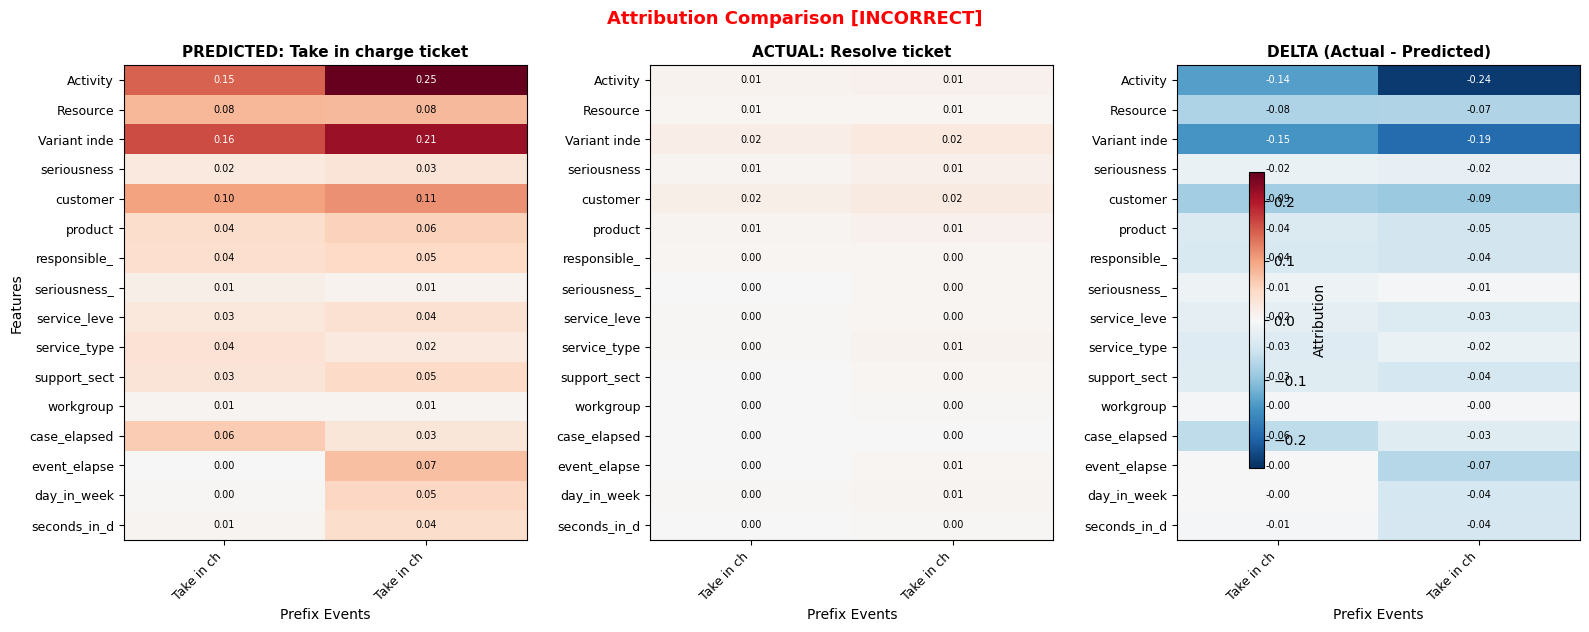

In [5]:
def to_numpy(x):
    if hasattr(x, 'detach'):
        return x.detach().cpu().numpy()
    return np.array(x)

def plot_comparison(attr_pred, attr_actual, feature_names, step_labels, 
                    pred_activity, gt_activity, is_correct):
    """Side-by-side comparison of predicted vs actual attributions."""
    n_features = len(feature_names)
    n_steps = len(step_labels)
    
    # Build matrices
    mat_pred = np.array([to_numpy(attr_pred.attributions[f]) for f in feature_names])
    mat_actual = np.array([to_numpy(attr_actual.attributions[f]) for f in feature_names])
    mat_delta = mat_actual - mat_pred
    
    # Find global vmax for consistent scaling
    vmax = max(np.abs(mat_pred).max(), np.abs(mat_actual).max(), np.abs(mat_delta).max())
    
    fig, axes = plt.subplots(1, 3, figsize=(16, max(6, n_features * 0.4)))
    
    titles = [
        f'PREDICTED: {pred_activity}',
        f'ACTUAL: {gt_activity}',
        f'DELTA (Actual - Predicted)'
    ]
    matrices = [mat_pred, mat_actual, mat_delta]
    
    for ax, mat, title in zip(axes, matrices, titles):
        im = ax.imshow(mat, cmap='RdBu_r', aspect='auto',
                      norm=TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax))
        
        ax.set_xticks(range(n_steps))
        ax.set_xticklabels([l[:10] for l in step_labels], rotation=45, ha='right', fontsize=9)
        ax.set_yticks(range(n_features))
        ax.set_yticklabels([f[:12] for f in feature_names], fontsize=9)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Prefix Events')
        
        # Add value annotations
        for i in range(n_features):
            for j in range(n_steps):
                val = mat[i, j]
                color = 'white' if abs(val) > vmax * 0.5 else 'black'
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', 
                       fontsize=7, color=color)
    
    axes[0].set_ylabel('Features')
    
    # Colorbar
    fig.colorbar(im, ax=axes, shrink=0.6, label='Attribution')
    
    status = "CORRECT" if is_correct else "INCORRECT"
    status_color = 'green' if is_correct else 'red'
    fig.suptitle(f'Attribution Comparison [{status}]', fontsize=13, fontweight='bold', color=status_color)
    plt.tight_layout()
    return fig, mat_pred, mat_actual, mat_delta

fig, mat_pred, mat_actual, mat_delta = plot_comparison(
    attr_predicted, attr_actual, feature_names, step_labels,
    pred_activity, gt_activity, is_correct
)
plt.show()

In [6]:
# Summary: which features differ most?
print(f"{'='*70}")
print(f"DELTA ANALYSIS: What would push toward the correct answer?")
print(f"{'='*70}")

# Total delta per feature
delta_totals = np.sum(mat_delta, axis=1)  # Sum across positions
sorted_idx = np.argsort(np.abs(delta_totals))[::-1]

print(f"\nFeatures with largest delta (Actual - Predicted):")
print(f"  Positive delta = feature pushes MORE toward actual class")
print(f"  Negative delta = feature pushes LESS toward actual class\n")

for rank, idx in enumerate(sorted_idx[:8], 1):
    feat = feature_names[idx]
    delta = delta_totals[idx]
    pred_val = np.sum(mat_pred[idx])
    actual_val = np.sum(mat_actual[idx])
    
    direction = "+" if delta > 0 else "-"
    print(f"  {rank}. {feat:20s}: delta={delta:+.4f}  (pred={pred_val:.4f}, actual={actual_val:.4f})")

DELTA ANALYSIS: What would push toward the correct answer?

Features with largest delta (Actual - Predicted):
  Positive delta = feature pushes MORE toward actual class
  Negative delta = feature pushes LESS toward actual class

  1. Activity            : delta=-0.3733  (pred=0.3931, actual=0.0198)
  2. Variant index       : delta=-0.3356  (pred=0.3754, actual=0.0399)
  3. customer            : delta=-0.1768  (pred=0.2138, actual=0.0370)
  4. Resource            : delta=-0.1511  (pred=0.1618, actual=0.0106)
  5. case_elapsed_time   : delta=-0.0915  (pred=0.0943, actual=0.0028)
  6. responsible_section : delta=-0.0820  (pred=0.0905, actual=0.0085)
  7. product             : delta=-0.0810  (pred=0.0999, actual=0.0189)
  8. support_section     : delta=-0.0739  (pred=0.0795, actual=0.0056)
